<a href="https://colab.research.google.com/github/ArduinoPLUS/aicar/blob/main/XORGate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **XOR 게이트 학습**

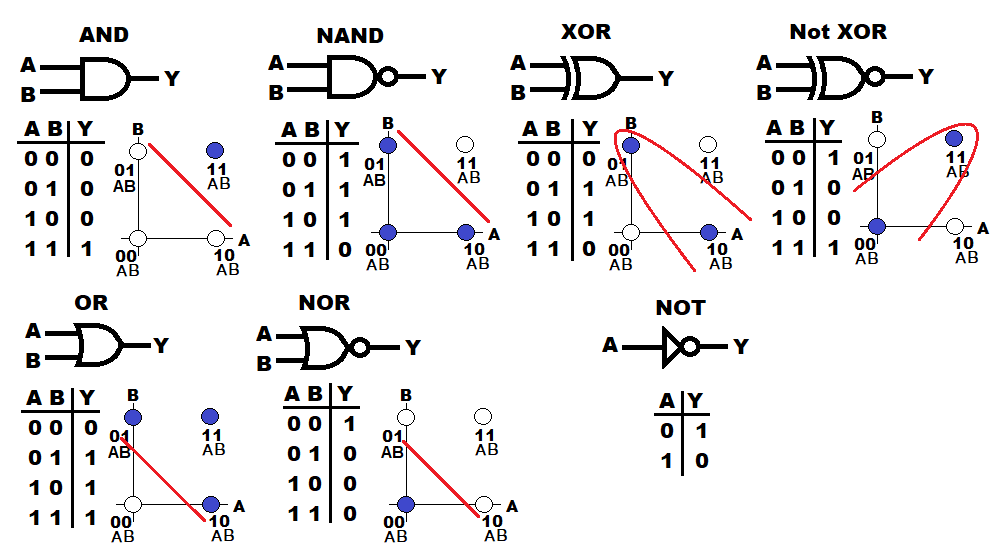

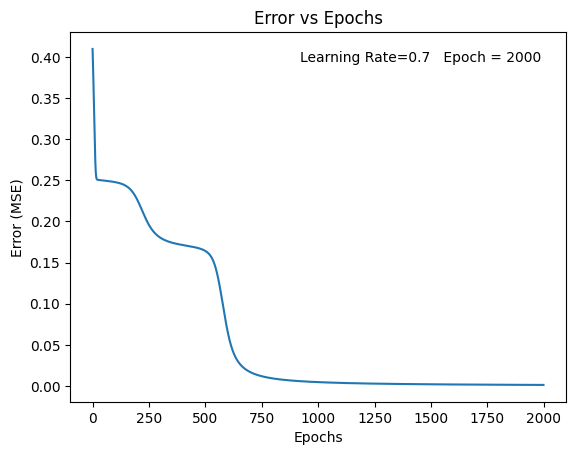

 A B       XOR        NXOR
[0,0] -> [[0.0387336  0.96260227]]
[0,1] -> [[0.96521771 0.03351671]]
[1,0] -> [[0.96545294 0.03341005]]
[1,1] -> [[0.0382722  0.96305353]]


In [26]:
################################################################################
# XOR Gate 학습                                                - XORGate.ipynb -
#
# 단일층의 딥러닝 클래스에 의하여 여러단의 딥러닝 층을 생성한다.
# 활성화 함수 Sigmoid 클래스, MSE 손실함수 클래스를 조합하여 딥러닝 네트웍 구성
#
#
################################################################################
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)  # 재현성을 위한 랜덤 시드

# ── 시그모이드 클래스 ────────────────────────────────
class Sigmoid:
    def forward(self, x):
        self.y = 1 / (1 + np.exp(-x))
        return self.y

    def backward(self):
        # 시그모이드 도함수: y * (1 - y)
        return self.y * (1 - self.y)

# --- 오차 클래스 --------------------------------------------------------------
class MSELoss:
    def forward(self, Y, D):
        self.Y = Y
        self.D = D
        return np.mean((Y - D) ** 2)

    def backward(self):
        # MSE 그래디언트
        return self.Y - self.D      # 손실 함수의 미분(계수 1/2 생략)
        #return (self.Y - self.D)/2.0      # 손실 함수의 미분(정확한 미분)

# --- 딥러닝 클래스 (선형 계층만, 활성화 제외) ---------------------------------
class DeepLearning:
    def __init__(self, input_size, output_size):
        # 가중치 W, 바이어스 B 초기화
        self.W = np.random.randn(input_size, output_size)
        self.B = np.random.randn(1, output_size)

    def forward(self, X):                          # 순전파 (선형)
        self.X = X
        self.S = np.dot(X, self.W) + self.B
        return self.S

    def backward(self, dS, learning_rate):         # 역전파 (선형)
        # dS: 이 계층 선형 출력(S)에 대한 그래디언트
        dW = np.dot(self.X.T, dS)
        dB = np.sum(dS, axis=0, keepdims=True)
        dX = np.dot(dS, self.W.T)                   # 이전 계층으로 전달할 그래디언트

        # 가중치 및 편향 업데이트
        self.W = self.W - learning_rate * dW
        self.B = self.B - learning_rate * dB
        return dX

# ==== 신경망 구성 (인스턴스 직접 생성) ========================================
# 2 입력 → 은닉층1(2) → 은닉층2(2) → 출력층(2)
layer3 = DeepLearning(2, 2)   # 입력 → 은닉층1
sig3 = Sigmoid()              # 활성화 함수 1
layer2 = DeepLearning(2, 2)   # 은닉층1 → 은닉층2
sig2 = Sigmoid()              # 활성화 함수 2
layer1 = DeepLearning(2, 2)   # 은닉층2 → 출력층
sig1 = Sigmoid()              # 활성화 함수 3
criterion = MSELoss()

# 학습 데이터(X)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])   # 2 입력 논리 게이트
# 목표(D) 데이터
D = np.array([[0, 1], [1, 0], [1, 0], [0, 1]]); epochs = 2000;  learning_rate = 0.7; m = ' A B       XOR        NXOR'
#D = np.array([[0, 1],[0, 1],[0, 1],[1, 0]]); epochs = 5000;  learning_rate = 10;     m = ' A B       AND        NAND'
#D = np.array([[0, 1],[1, 0],[1, 0],[1, 0]]); epochs = 20000; learning_rate = 0.7;    m = ' A B       OR         NOR'

# --- 학습 ---------------------------------------------------------------------
errors = []

for i in range(epochs):
    # 순전파
    Y3 = sig3.forward(layer3.forward(X))
    Y2 = sig2.forward(layer2.forward(Y3))
    Y1 = sig1.forward(layer1.forward(Y2))
    # 오차 계산 (MSE)
    error = criterion.forward(Y1, D)
    errors.append(error)
    # 역전파
    dY = criterion.backward()
    dY = layer1.backward(dY * sig1.backward(), learning_rate)
    dY = layer2.backward(dY * sig2.backward(), learning_rate)
    dY = layer3.backward(dY * sig3.backward(), learning_rate)

# --- 오차 그래프 출력 ---------------------------------------------------------
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Error (MSE)")
plt.title("Error vs Epochs")
plt.text(0.95, 0.95, f'Learning Rate={learning_rate}   Epoch = {epochs}',
         transform=plt.gca().transAxes, ha='right', va='top')
plt.show()

# 학습 결과 확인
def predict(X):
    s3 = layer3.forward(X)
    y3 = sig3.forward(s3)
    s2 = layer2.forward(y3)
    y2 = sig2.forward(s2)
    s1 = layer1.forward(y2)
    y1 = sig1.forward(s1)

    return y1

# ------------------------------------------------------------------------------
print(m)
print('[0,0] ->', predict(np.array([[0, 0]])))
print('[0,1] ->', predict(np.array([[0, 1]])))
print('[1,0] ->', predict(np.array([[1, 0]])))
print('[1,1] ->', predict(np.array([[1, 1]])))
